In [1]:
import numpy as np
import scipy as sp
import krylov as kr
import ham_generator as gen
import matplotlib.pyplot as plt
import networkx as nx

In [20]:
#global variables 
DIM = 6
EPS = 1e-15

psi0 = np.zeros(shape=DIM, dtype=complex)
psi0[0] = 1.0+0.j

In [59]:
#test of computation

H_test = gen.router(theta=np.pi)

#print(H_test)

compl_test = kr.get_complexity(H_test, psi0, threshold=EPS)[1]

#print(H_kryl)

print(compl_test.real)

#Ho sbagliato il conto analitico. Questo rispetta il limite superiore; forse gli indiani avevano ragione

1.394444444444444


In [56]:
n_thetas = 500000
theta_max = 2*np.pi

thetas = np.linspace(0, theta_max, n_thetas)

compls = np.ndarray(shape=n_thetas, dtype=complex)

for i in range(n_thetas):
    H = gen.router(theta=thetas[i])
    compls[i] = kr.get_complexity(H, psi0, EPS)[1]

/tmp/ipykernel_5628/1884906638.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axx.legend()


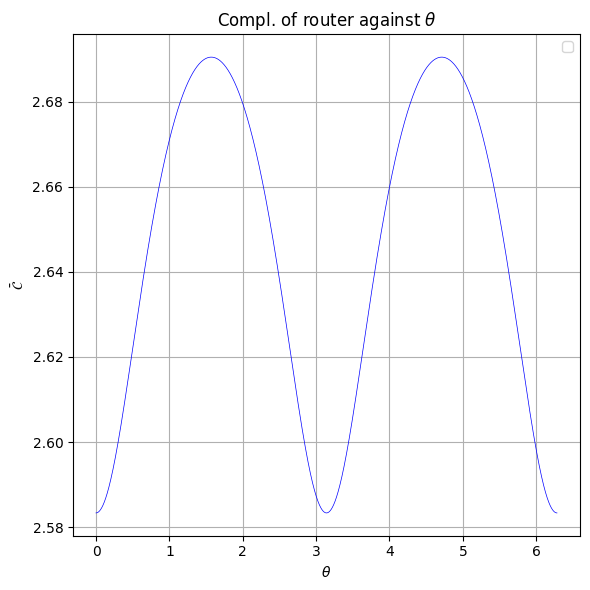

In [66]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

axx.set_title(r"Compl. of router against $\theta$")
axx.grid(True)

axx.set_xlabel(r"$\theta$")
axx.set_ylabel(r"$\bar{\mathcal{C}}$")

#axx.set_ylim(bottom=-0.1+min(compls.real[1:-2]), top=max(compls.real[1:-2]))
axx.plot(thetas[1:-2], compls.real[1:-2], linewidth=0.5, color="blue")

#axx.axhline(y=0.5*(4-1), label="Degenerate upper-bound", linestyle="--", color="red")
#axx.axhline(y=0.5*(6-1), label="Non-deg. upper-bound", linestyle="--", color="red")

axx.legend()

plt.show()
